# Week 9 — Análisis de errores y slicing

**Proyecto:** Análisis de sentimiento en noticias macroeconómicas para señales USD/PEN.  
**Objetivo:** identificar slices problemáticos, analizar falsos positivos/falsos negativos, estimar intervalos de confianza y probar una mitigación mediante ajuste de umbral.

Este notebook continúa la Week 8. Usa el dataset exportado para GitHub Pages y las predicciones del modelo ganador.


In [1]:
# =========================
# 1. Configuración inicial
# =========================

from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

LOGS_DIR = PROJECT_ROOT / "logs"
FIGS_DIR = PROJECT_ROOT / "figs"
DOCS_DATA_DIR = PROJECT_ROOT / "docs" / "data"

LOGS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("LOGS_DIR:", LOGS_DIR)
print("FIGS_DIR:", FIGS_DIR)
print("DOCS_DATA_DIR:", DOCS_DATA_DIR)


PROJECT_ROOT: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline
LOGS_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs
FIGS_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\figs
DOCS_DATA_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\docs\data


## 2. Carga del dataset Week 8

Se utiliza `docs/data/week8_dashboard_data.csv`, porque contiene variables modelables, `target_up`, probabilidades y predicciones del Random Forest ganador.


In [2]:
# =========================
# 2. Cargar dataset Week 8
# =========================

dashboard_path = DOCS_DATA_DIR / "week8_dashboard_data.csv"

if not dashboard_path.exists():
    raise FileNotFoundError(f"No se encontró: {dashboard_path}")

df = pd.read_csv(dashboard_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Shape:", df.shape)
display(df.head())
print(df.columns.tolist())


Shape: (88, 26)


,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,open,close,...,signal_baseline,hit_baseline,prob_up_var1,pred_up_var1,signal_var1,hit_var1,prob_up_rf,pred_up_rf,signal_rf,hit_rf
0,2025-07-09,USD/PEN,28,0.106546,0.081561,0.035714,0.0,0.964286,3.542000,3.542000,...,UP,False,0.852273,1,UP,False,0.226354,0,NO_UP,True
1,2025-07-14,USD/PEN,29,0.152271,0.106098,0.068966,0.0,0.931034,3.476722,3.476722,...,UP,False,0.795455,1,UP,False,0.087309,0,NO_UP,True
2,2025-07-16,USD/PEN,28,0.189611,0.134425,0.142857,0.0,0.857143,3.560500,3.560500,...,UP,False,0.772727,1,UP,False,0.315070,0,NO_UP,True
3,2025-07-17,USD/PEN,29,0.105031,0.079039,0.068966,0.0,0.931034,3.544500,3.544500,...,UP,False,0.943182,1,UP,False,0.052360,0,NO_UP,True
4,2025-07-22,USD/PEN,29,0.136440,0.098304,0.068966,0.0,0.931034,3.559000,3.559000,...,UP,False,0.897727,1,UP,False,0.031213,0,NO_UP,True


['date', 'asset', 'n_news_total', 'sent_index_mean', 'sent_index_strength', 'share_pos', 'share_neg', 'share_neu', 'open', 'close', 'fx_diff', 'fx_return', 'real_dir', 'target_up', 'prob_up_baseline', 'pred_up_baseline', 'signal_baseline', 'hit_baseline', 'prob_up_var1', 'pred_up_var1', 'signal_var1', 'hit_var1', 'prob_up_rf', 'pred_up_rf', 'signal_rf', 'hit_rf']


## 3. Selección del modelo base

El análisis se realiza sobre el **Random Forest ganador**:

- `prob_up_rf`: probabilidad de subida.
- `pred_up_rf`: predicción con umbral 0.50.
- `target_up`: valor real.


In [3]:
# =========================
# 3. Preparar columnas del modelo base
# =========================

MODEL_NAME = "Random Forest ganador"
PROB_COL = "prob_up_rf"
PRED_COL = "pred_up_rf"
TARGET_COL = "target_up"

required_cols = [
    "date", TARGET_COL, PROB_COL, PRED_COL,
    "n_news_total", "sent_index_mean", "sent_index_strength",
    "share_pos", "share_neg", "share_neu"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas necesarias: {missing}")

df_model = df.dropna(subset=[TARGET_COL, PROB_COL]).copy()
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)
df_model[PRED_COL] = df_model[PRED_COL].astype(int)

print("Registros con predicción RF:", len(df_model))
print("Distribución target:")
display(df_model[TARGET_COL].value_counts().rename(index={0:"NO_UP", 1:"UP"}))


Registros con predicción RF: 88
Distribución target:


target_up
NO_UP    47
UP       41
Name: count, dtype: int64

## 4. Métricas globales del modelo base

Estas métricas serán la línea base para comparar slices y mitigación.


In [4]:
# =========================
# 4. Funciones y métricas globales
# =========================

def compute_metrics(y_true, y_pred, y_score=None):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    metrics = {
        "n": int(len(y_true)),
        "accuracy": accuracy_score(y_true, y_pred) if len(y_true) else np.nan,
        "precision": precision_score(y_true, y_pred, zero_division=0) if len(y_true) else np.nan,
        "recall": recall_score(y_true, y_pred, zero_division=0) if len(y_true) else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0) if len(y_true) else np.nan,
    }
    if y_score is not None and len(np.unique(y_true)) > 1:
        metrics["pr_auc"] = average_precision_score(y_true, y_score)
    else:
        metrics["pr_auc"] = np.nan
    return metrics

def confusion_counts(y_true, y_pred):
    cm_local = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm_local.ravel()
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

global_base = compute_metrics(df_model[TARGET_COL], df_model[PRED_COL], df_model[PROB_COL])
global_base_df = pd.DataFrame([{"model": MODEL_NAME, "threshold": 0.50, **global_base}])

display(global_base_df)
global_base_df.to_csv(LOGS_DIR / "week9_global_base_metrics.csv", index=False, encoding="utf-8-sig")


,model,threshold,n,accuracy,precision,recall,f1,pr_auc
0,Random Forest ganador,0.5,88,0.784091,0.866667,0.634146,0.732394,0.853188


## 5. Matriz de confusión y tipos de error

Se etiquetan los casos como:

- **TP:** Real UP y predicho UP.
- **TN:** Real NO_UP y predicho NO_UP.
- **FP:** Real NO_UP pero predicho UP.
- **FN:** Real UP pero predicho NO_UP.


In [5]:
# =========================
# 5. Matriz de confusión y tipos de error
# =========================

def assign_error_type(row, target_col=TARGET_COL, pred_col=PRED_COL):
    y = int(row[target_col])
    p = int(row[pred_col])
    if y == 1 and p == 1:
        return "TP"
    if y == 0 and p == 0:
        return "TN"
    if y == 0 and p == 1:
        return "FP"
    if y == 1 and p == 0:
        return "FN"

df_model["error_type_base"] = df_model.apply(assign_error_type, axis=1)

cm = confusion_matrix(df_model[TARGET_COL], df_model[PRED_COL], labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["Real_NO_UP", "Real_UP"], columns=["Pred_NO_UP", "Pred_UP"])

display(cm_df)
display(df_model["error_type_base"].value_counts())

cm_df.to_csv(LOGS_DIR / "week9_confusion_matrix_base.csv", encoding="utf-8-sig")
df_model.to_csv(LOGS_DIR / "week9_predictions_with_error_type.csv", index=False, encoding="utf-8-sig")


,Pred_NO_UP,Pred_UP
Real_NO_UP,43,4
Real_UP,15,26


error_type_base
TN    43
TP    26
FN    15
FP     4
Name: count, dtype: int64

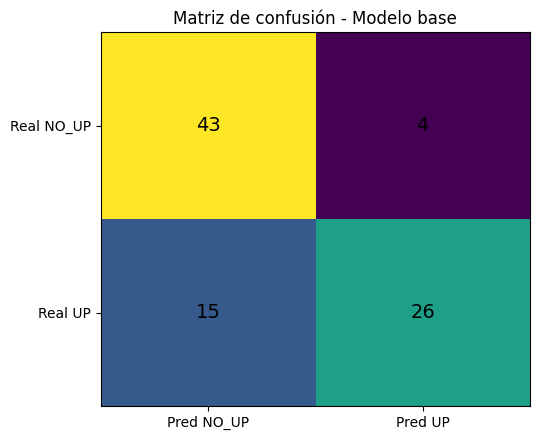

In [6]:
# =========================
# 5.1 Gráfico matriz de confusión base
# =========================

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(cm, aspect="auto")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred NO_UP", "Pred UP"])
ax.set_yticklabels(["Real NO_UP", "Real UP"])
ax.set_title("Matriz de confusión - Modelo base")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)

plt.tight_layout()
plt.savefig(FIGS_DIR / "week9_confusion_matrix_base.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Falsos positivos y falsos negativos

Esta sección exporta los errores para revisión manual. Los **falsos negativos** son importantes si se quiere detectar más días `UP`.


In [7]:
# =========================
# 6. Falsos positivos y falsos negativos
# =========================

inspect_cols = [
    "date", "target_up", "prob_up_rf", "pred_up_rf", "error_type_base",
    "n_news_total", "sent_index_mean", "sent_index_strength",
    "share_pos", "share_neg", "share_neu", "open", "close", "fx_return", "real_dir"
]
inspect_cols = [c for c in inspect_cols if c in df_model.columns]

false_negatives = df_model[df_model["error_type_base"] == "FN"][inspect_cols].copy()
false_positives = df_model[df_model["error_type_base"] == "FP"][inspect_cols].copy()

false_negatives.to_csv(LOGS_DIR / "week9_false_negatives.csv", index=False, encoding="utf-8-sig")
false_positives.to_csv(LOGS_DIR / "week9_false_positives.csv", index=False, encoding="utf-8-sig")

print("Falsos negativos:", len(false_negatives))
display(false_negatives.head(10))

print("Falsos positivos:", len(false_positives))
display(false_positives.head(10))


Falsos negativos: 15


,date,target_up,prob_up_rf,pred_up_rf,error_type_base,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,open,close,fx_return,real_dir
50,2026-02-09,1,0.461650,0,FN,29,0.106000,0.079928,0.034483,0.000000,0.965517,3.286228,3.287243,0.000309,UP
52,2026-02-11,1,0.492997,0,FN,30,0.153844,0.107210,0.100000,0.000000,0.900000,3.292374,3.356000,0.019325,UP
61,2026-03-06,1,0.140635,0,FN,30,0.106748,0.083590,0.033333,0.000000,0.966667,3.341670,3.342375,0.000211,UP
62,2026-03-10,1,0.087309,0,FN,27,0.139083,0.097628,0.074074,0.000000,0.925926,3.395020,3.487000,0.027093,UP
64,2026-03-12,1,0.440232,0,FN,31,0.080887,0.058522,0.000000,0.032258,0.967742,3.370949,3.417000,0.013661,UP
66,2026-03-19,1,0.223809,0,FN,30,0.076373,0.064698,0.000000,0.000000,1.000000,3.366413,3.426000,0.017700,UP
72,2026-04-01,1,0.434156,0,FN,29,0.103733,0.077921,0.034483,0.000000,0.965517,3.409713,3.495000,0.025013,UP
76,2026-04-08,1,0.377101,0,FN,28,0.128288,0.094279,0.035714,0.000000,0.964286,3.322124,3.425000,0.030967,UP
77,2026-04-09,1,0.241936,0,FN,1,0.556626,0.318593,1.000000,0.000000,0.000000,3.314225,3.380500,0.019997,UP
79,2026-04-16,1,0.088348,0,FN,27,0.053479,0.045303,0.000000,0.037037,0.962963,3.312089,3.439000,0.038317,UP


Falsos positivos: 4


,date,target_up,prob_up_rf,pred_up_rf,error_type_base,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,open,close,fx_return,real_dir
14,2025-08-14,0,0.675076,1,FP,1,0.045859,0.041683,0.000000,0.000000,1.000000,3.540000,3.540000,0.000000,FLAT
27,2025-10-28,0,0.570281,1,FP,27,0.125682,0.099524,0.074074,0.000000,0.925926,3.385000,3.385000,0.000000,FLAT
69,2026-03-26,0,0.643000,1,FP,27,0.045851,0.043455,0.000000,0.037037,0.962963,3.460000,3.460000,0.000000,FLAT
82,2026-04-27,0,0.724434,1,FP,26,0.122899,0.087941,0.038462,0.000000,0.961538,3.420261,3.393218,-0.007907,DOWN


## 7. Construcción de slices

Se construyen 5 slices:

1. Volumen de noticias.
2. Neutralidad del sentimiento.
3. Intensidad del sentimiento.
4. Ventana temporal.
5. Confianza del modelo.


In [8]:
# =========================
# 7. Crear slices
# =========================

df_slices = df_model.copy()

# Slice 1: volumen de noticias por terciles
df_slices["slice_news_volume"] = pd.qcut(
    df_slices["n_news_total"].rank(method="first"),
    q=3,
    labels=["volumen_bajo", "volumen_medio", "volumen_alto"]
)

# Slice 2: alta neutralidad
neutral_threshold = df_slices["share_neu"].quantile(0.75)
df_slices["slice_neutrality"] = np.where(
    df_slices["share_neu"] >= neutral_threshold,
    "alta_neutralidad",
    "neutralidad_no_alta"
)

# Slice 3: intensidad del sentimiento por terciles
df_slices["slice_strength"] = pd.qcut(
    df_slices["sent_index_strength"].rank(method="first"),
    q=3,
    labels=["intensidad_baja", "intensidad_media", "intensidad_alta"]
)

# Slice 4: ventana temporal
df_slices = df_slices.sort_values("date").reset_index(drop=True)
df_slices["slice_time_window"] = pd.qcut(
    df_slices.index + 1,
    q=3,
    labels=["inicio_periodo", "medio_periodo", "final_periodo"]
)

# Slice 5: confianza del modelo
df_slices["confidence_distance"] = (df_slices[PROB_COL] - 0.5).abs()
df_slices["slice_confidence"] = pd.qcut(
    df_slices["confidence_distance"].rank(method="first"),
    q=3,
    labels=["confianza_baja", "confianza_media", "confianza_alta"]
)

slice_columns = [
    "slice_news_volume",
    "slice_neutrality",
    "slice_strength",
    "slice_time_window",
    "slice_confidence"
]

for col in slice_columns:
    print("\n", col)
    display(df_slices[col].value_counts())

df_slices.to_csv(LOGS_DIR / "week9_dataset_with_slices.csv", index=False, encoding="utf-8-sig")



 slice_news_volume


slice_news_volume
volumen_bajo     30
volumen_medio    29
volumen_alto     29
Name: count, dtype: int64


 slice_neutrality


slice_neutrality
neutralidad_no_alta    63
alta_neutralidad       25
Name: count, dtype: int64


 slice_strength


slice_strength
intensidad_baja     30
intensidad_media    29
intensidad_alta     29
Name: count, dtype: int64


 slice_time_window


slice_time_window
inicio_periodo    30
medio_periodo     29
final_periodo     29
Name: count, dtype: int64


 slice_confidence


slice_confidence
confianza_baja     30
confianza_media    29
confianza_alta     29
Name: count, dtype: int64

## 8. Métricas por slice

Para cada slice se calculan: n, Accuracy, Precision, Recall, F1, PR-AUC, TP, FP, FN y TN.


In [9]:
# =========================
# 8. Métricas por slice
# =========================

def metrics_for_subset(sub, group_name, slice_value, threshold=0.50):
    y_true = sub[TARGET_COL].astype(int).values
    y_score = sub[PROB_COL].values
    y_pred = (y_score >= threshold).astype(int)
    m = compute_metrics(y_true, y_pred, y_score)
    c = confusion_counts(y_true, y_pred)
    return {
        "slice_group": group_name,
        "slice_value": str(slice_value),
        "threshold": threshold,
        **m,
        **c
    }

slice_metrics = []

for slice_col in slice_columns:
    for val, sub in df_slices.groupby(slice_col):
        slice_metrics.append(metrics_for_subset(sub, slice_col, val, threshold=0.50))

slice_metrics_df = pd.DataFrame(slice_metrics)
slice_metrics_df = slice_metrics_df.sort_values(["slice_group", "recall", "pr_auc"], ascending=[True, True, True])

display(slice_metrics_df)
slice_metrics_df.to_csv(LOGS_DIR / "week9_slice_metrics_base.csv", index=False, encoding="utf-8-sig")


,slice_group,slice_value,threshold,n,accuracy,precision,recall,f1,pr_auc,tn,fp,fn,tp
11,slice_confidence,confianza_baja,0.5,30,0.666667,0.818182,0.529412,0.642857,0.749978,11,2,8,9
12,slice_confidence,confianza_media,0.5,29,0.793103,0.800000,0.666667,0.727273,0.756779,15,2,4,8
13,slice_confidence,confianza_alta,0.5,29,0.896552,1.000000,0.750000,0.857143,0.915028,17,0,3,9
4,slice_neutrality,neutralidad_no_alta,0.5,63,0.761905,0.863636,0.612903,0.716981,0.847226,29,3,12,19
3,slice_neutrality,alta_neutralidad,0.5,25,0.840000,0.875000,0.700000,0.777778,0.887664,14,1,3,7
1,slice_news_volume,volumen_medio,0.5,29,0.758621,0.600000,0.375000,0.461538,0.523565,19,2,5,3
2,slice_news_volume,volumen_alto,0.5,29,0.758621,1.000000,0.666667,0.800000,0.959037,8,0,7,14
0,slice_news_volume,volumen_bajo,0.5,30,0.833333,0.818182,0.750000,0.782609,0.924806,16,2,3,9
5,slice_strength,intensidad_baja,0.5,30,0.700000,0.833333,0.588235,0.689655,0.831563,11,2,7,10
6,slice_strength,intensidad_media,0.5,29,0.827586,0.875000,0.636364,0.736842,0.804389,17,1,4,7


## 9. Bootstrap para intervalos de confianza

Se estima intervalo de confianza al 95% para F1, Recall, Precision, Accuracy y PR-AUC por slice.


In [10]:
# =========================
# 9. Bootstrap para intervalos de confianza
# =========================

def bootstrap_metric_ci(y_true, y_score, metric_name="f1", threshold=0.50, n_boot=1000, alpha=0.05, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    n = len(y_true)

    if n < 5:
        return (np.nan, np.nan, np.nan)

    vals = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        ys = y_score[idx]
        yp = (ys >= threshold).astype(int)

        if metric_name == "f1":
            val = f1_score(yt, yp, zero_division=0)
        elif metric_name == "recall":
            val = recall_score(yt, yp, zero_division=0)
        elif metric_name == "precision":
            val = precision_score(yt, yp, zero_division=0)
        elif metric_name == "accuracy":
            val = accuracy_score(yt, yp)
        elif metric_name == "pr_auc":
            if len(np.unique(yt)) > 1:
                val = average_precision_score(yt, ys)
            else:
                continue
        vals.append(val)

    if not vals:
        return (np.nan, np.nan, np.nan)

    vals = np.asarray(vals)
    return np.mean(vals), np.quantile(vals, alpha/2), np.quantile(vals, 1-alpha/2)

bootstrap_rows = []

for slice_col in slice_columns:
    for val, sub in df_slices.groupby(slice_col):
        for metric in ["f1", "recall", "precision", "accuracy", "pr_auc"]:
            mean_val, lo, hi = bootstrap_metric_ci(
                sub[TARGET_COL].values,
                sub[PROB_COL].values,
                metric_name=metric,
                threshold=0.50,
                n_boot=1000
            )
            bootstrap_rows.append({
                "slice_group": slice_col,
                "slice_value": str(val),
                "metric": metric,
                "mean_bootstrap": mean_val,
                "ci_95_low": lo,
                "ci_95_high": hi,
                "n": len(sub)
            })

bootstrap_df = pd.DataFrame(bootstrap_rows)
display(bootstrap_df.head(20))
bootstrap_df.to_csv(LOGS_DIR / "week9_slice_bootstrap_ci.csv", index=False, encoding="utf-8-sig")


,slice_group,slice_value,metric,mean_bootstrap,ci_95_low,ci_95_high,n
0,slice_news_volume,volumen_bajo,f1,0.774243,0.571429,0.937592,30
1,slice_news_volume,volumen_bajo,recall,0.749487,0.500000,1.000000,30
2,slice_news_volume,volumen_bajo,precision,0.817840,0.571429,1.000000,30
3,slice_news_volume,volumen_bajo,accuracy,0.833033,0.700000,0.933333,30
4,slice_news_volume,volumen_bajo,pr_auc,0.924439,0.796095,1.000000,30
5,slice_news_volume,volumen_medio,f1,0.446318,0.000000,0.769231,29
6,slice_news_volume,volumen_medio,recall,0.379026,0.000000,0.750694,29
7,slice_news_volume,volumen_medio,precision,0.603296,0.000000,1.000000,29
8,slice_news_volume,volumen_medio,accuracy,0.760724,0.586207,0.896552,29
9,slice_news_volume,volumen_medio,pr_auc,0.558247,0.218478,0.850847,29


## 10. Identificación automática de slices problemáticos

Se priorizan slices con n suficiente, bajo Recall, bajo F1 y mayor concentración de falsos negativos.


In [11]:
# =========================
# 10. Identificar slices problemáticos
# =========================

MIN_N = 10

problematic = slice_metrics_df[slice_metrics_df["n"] >= MIN_N].copy()
problematic["problem_score"] = (1 - problematic["recall"]) + (problematic["fn"] / problematic["n"])
problematic = problematic.sort_values("problem_score", ascending=False)

top_problematic = problematic.head(5)
display(top_problematic)

top_problematic.to_csv(LOGS_DIR / "week9_top_problematic_slices.csv", index=False, encoding="utf-8-sig")


,slice_group,slice_value,threshold,n,accuracy,precision,recall,f1,pr_auc,tn,fp,fn,tp,problem_score
10,slice_time_window,final_periodo,0.5,29,0.482759,0.800000,0.380952,0.516129,0.801947,6,2,13,8,1.067323
8,slice_time_window,inicio_periodo,0.5,30,0.933333,0.000000,0.000000,0.000000,NaN,28,2,0,0,1.000000
1,slice_news_volume,volumen_medio,0.5,29,0.758621,0.600000,0.375000,0.461538,0.523565,19,2,5,3,0.797414
11,slice_confidence,confianza_baja,0.5,30,0.666667,0.818182,0.529412,0.642857,0.749978,11,2,8,9,0.737255
5,slice_strength,intensidad_baja,0.5,30,0.700000,0.833333,0.588235,0.689655,0.831563,11,2,7,10,0.645098


## 11. Visualizaciones por slice

Figuras para usar en el informe Overleaf.


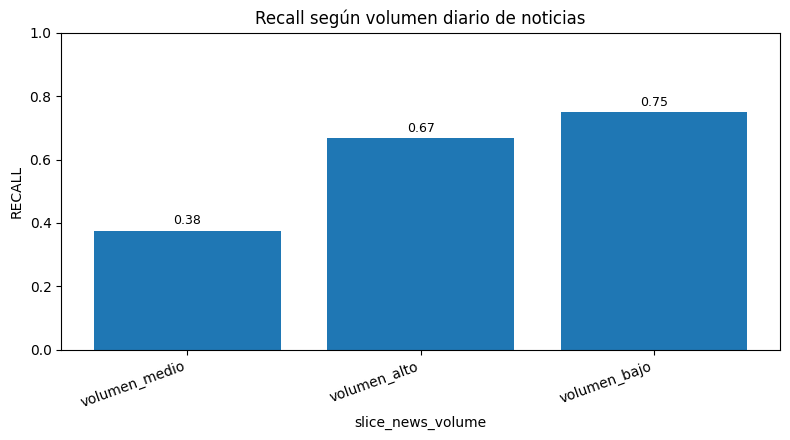

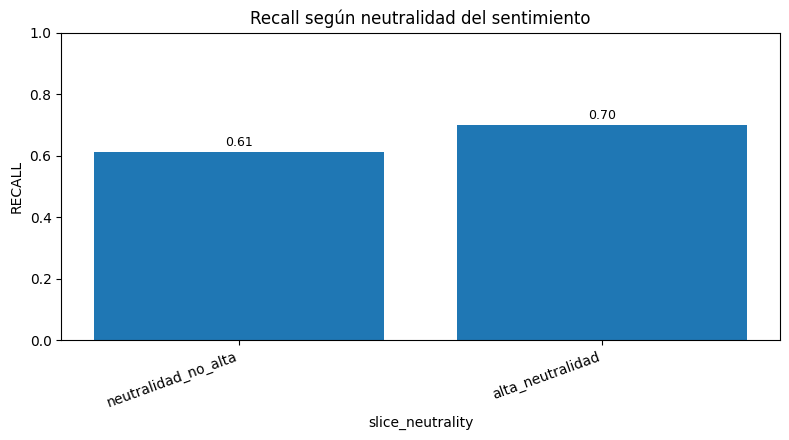

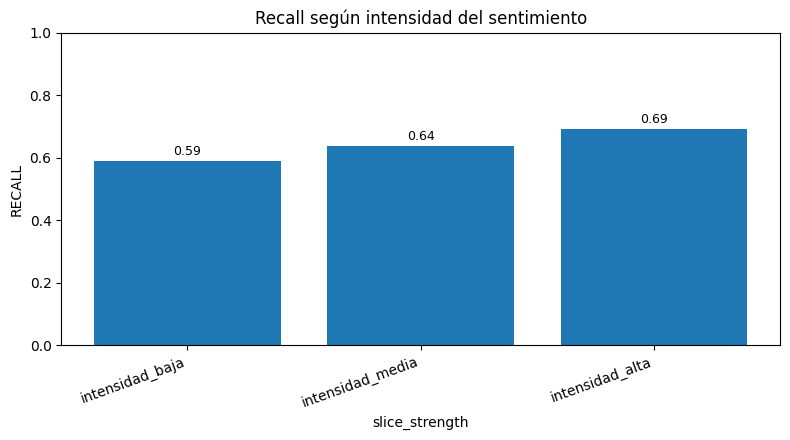

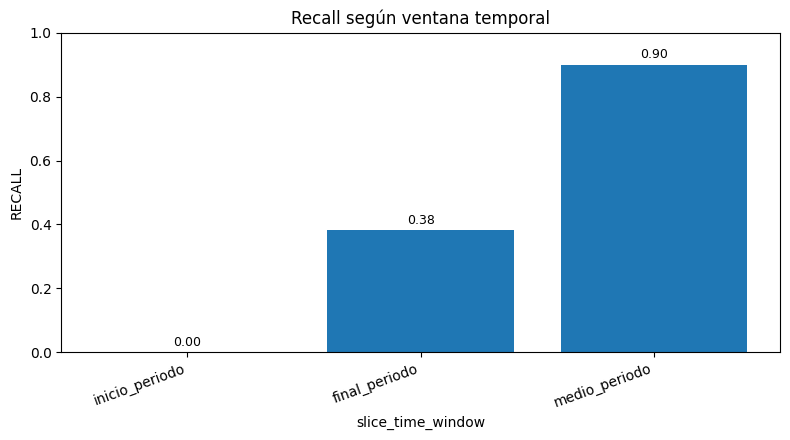

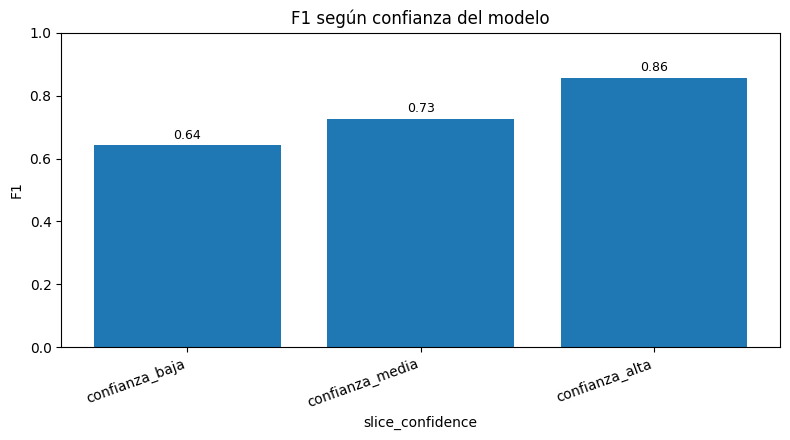

In [12]:
# =========================
# 11. Gráficos por slice
# =========================

def plot_slice_metric(slice_metrics_df, slice_group, metric="recall", filename=None, title=None):
    data = slice_metrics_df[slice_metrics_df["slice_group"] == slice_group].copy()
    data = data.sort_values(metric)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(data["slice_value"], data[metric])
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric.upper())
    ax.set_xlabel(slice_group)
    ax.set_title(title or f"{metric.upper()} por slice: {slice_group}")

    for i, v in enumerate(data[metric]):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    if filename:
        plt.savefig(FIGS_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_slice_metric(slice_metrics_df, "slice_news_volume", "recall", "week9_slice_news_volume_recall.png", "Recall según volumen diario de noticias")
plot_slice_metric(slice_metrics_df, "slice_neutrality", "recall", "week9_slice_neutrality_recall.png", "Recall según neutralidad del sentimiento")
plot_slice_metric(slice_metrics_df, "slice_strength", "recall", "week9_slice_strength_recall.png", "Recall según intensidad del sentimiento")
plot_slice_metric(slice_metrics_df, "slice_time_window", "recall", "week9_slice_time_window_recall.png", "Recall según ventana temporal")
plot_slice_metric(slice_metrics_df, "slice_confidence", "f1", "week9_slice_confidence_f1.png", "F1 según confianza del modelo")


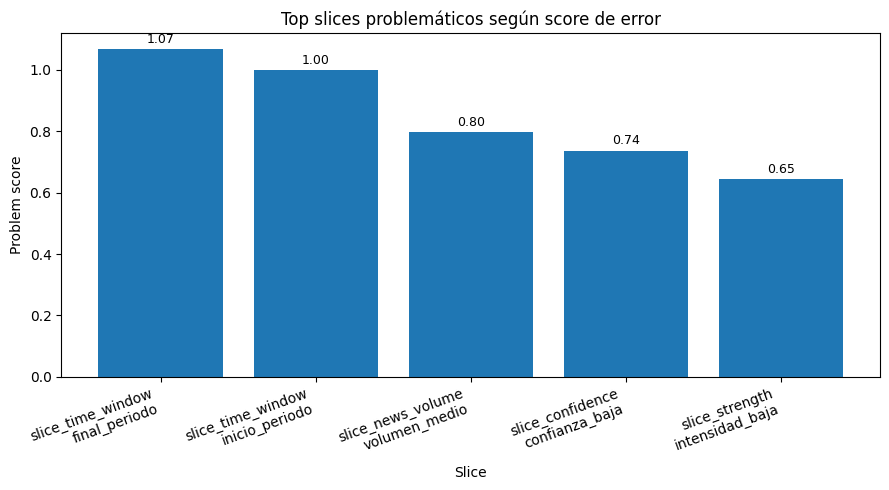

In [13]:
# =========================
# 11.1 Gráfico top slices problemáticos
# =========================

plot_df = top_problematic.copy()
plot_df["slice_label"] = plot_df["slice_group"] + "\n" + plot_df["slice_value"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["slice_label"], plot_df["problem_score"])
ax.set_title("Top slices problemáticos según score de error")
ax.set_ylabel("Problem score")
ax.set_xlabel("Slice")

for i, v in enumerate(plot_df["problem_score"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGS_DIR / "week9_top_problematic_slices.png", dpi=180, bbox_inches="tight")
plt.show()


## 12. Interpretación preliminar

Texto base para redactar el informe.


In [14]:
# =========================
# 12. Interpretación preliminar automática
# =========================

for _, row in top_problematic.iterrows():
    print("--------------------------------------------------")
    print(f"Slice problemático: {row['slice_group']} = {row['slice_value']}")
    print(f"n = {row['n']}")
    print(f"Recall = {row['recall']:.3f}")
    print(f"F1 = {row['f1']:.3f}")
    print(f"FN = {row['fn']}")
    print(f"FP = {row['fp']}")

    if "news_volume" in row["slice_group"]:
        print("Causa probable: menor volumen informativo puede reducir la estabilidad del indicador diario de sentimiento.")
    elif "neutrality" in row["slice_group"]:
        print("Causa probable: alta neutralidad puede disminuir la separación entre días UP y NO_UP.")
    elif "strength" in row["slice_group"]:
        print("Causa probable: baja o alta intensidad puede reflejar señales débiles o extremos poco frecuentes.")
    elif "time_window" in row["slice_group"]:
        print("Causa probable: posible drift temporal o cambio de régimen en la relación sentimiento-USD/PEN.")
    elif "confidence" in row["slice_group"]:
        print("Causa probable: probabilidades cercanas al umbral implican mayor incertidumbre del modelo.")


--------------------------------------------------
Slice problemático: slice_time_window = final_periodo
n = 29
Recall = 0.381
F1 = 0.516
FN = 13
FP = 2
Causa probable: posible drift temporal o cambio de régimen en la relación sentimiento-USD/PEN.
--------------------------------------------------
Slice problemático: slice_time_window = inicio_periodo
n = 30
Recall = 0.000
F1 = 0.000
FN = 0
FP = 2
Causa probable: posible drift temporal o cambio de régimen en la relación sentimiento-USD/PEN.
--------------------------------------------------
Slice problemático: slice_news_volume = volumen_medio
n = 29
Recall = 0.375
F1 = 0.462
FN = 5
FP = 2
Causa probable: menor volumen informativo puede reducir la estabilidad del indicador diario de sentimiento.
--------------------------------------------------
Slice problemático: slice_confidence = confianza_baja
n = 30
Recall = 0.529
F1 = 0.643
FN = 8
FP = 2
Causa probable: probabilidades cercanas al umbral implican mayor incertidumbre del modelo.
-

## 13. Mitigación: ajuste del umbral

La mitigación consiste en buscar un umbral alternativo para mejorar Recall/F1 sin deteriorar demasiado Accuracy.


In [15]:
# =========================
# 13. Threshold tuning
# =========================

thresholds = np.round(np.arange(0.20, 0.81, 0.01), 2)
threshold_rows = []

y_true = df_slices[TARGET_COL].astype(int).values
y_score = df_slices[PROB_COL].values

for th in thresholds:
    y_pred = (y_score >= th).astype(int)
    m = compute_metrics(y_true, y_pred, y_score)
    c = confusion_counts(y_true, y_pred)
    threshold_rows.append({"threshold": th, **m, **c})

threshold_df = pd.DataFrame(threshold_rows)

# Criterio:
# Maximizar F1 con restricción de no bajar accuracy más de 5 puntos frente al baseline
base_accuracy = global_base["accuracy"]
min_accuracy_allowed = max(0, base_accuracy - 0.05)

candidate_df = threshold_df[threshold_df["accuracy"] >= min_accuracy_allowed].copy()
candidate_df = candidate_df.sort_values(["f1", "recall"], ascending=False)

best_threshold_row = candidate_df.iloc[0]
best_threshold = float(best_threshold_row["threshold"])

print("Accuracy base:", base_accuracy)
print("Accuracy mínima permitida:", min_accuracy_allowed)
print("Mejor umbral elegido:", best_threshold)

display(candidate_df.head(10))

threshold_df.to_csv(LOGS_DIR / "week9_threshold_tuning.csv", index=False, encoding="utf-8-sig")
pd.DataFrame([best_threshold_row]).to_csv(LOGS_DIR / "week9_best_threshold.csv", index=False, encoding="utf-8-sig")


Accuracy base: 0.7840909090909091
Accuracy mínima permitida: 0.734090909090909
Mejor umbral elegido: 0.43


,threshold,n,accuracy,precision,recall,f1,pr_auc,tn,fp,fn,tp
23,0.43,88,0.818182,0.804878,0.804878,0.804878,0.853188,39,8,8,33
21,0.41,88,0.806818,0.785714,0.804878,0.795181,0.853188,38,9,8,33
22,0.42,88,0.806818,0.785714,0.804878,0.795181,0.853188,38,9,8,33
24,0.44,88,0.818182,0.837838,0.756098,0.794872,0.853188,41,6,10,31
25,0.45,88,0.818182,0.857143,0.731707,0.789474,0.853188,42,5,11,30
20,0.40,88,0.784091,0.750000,0.804878,0.776471,0.853188,36,11,8,33
26,0.46,88,0.806818,0.852941,0.707317,0.773333,0.853188,42,5,12,29
19,0.39,88,0.772727,0.733333,0.804878,0.767442,0.853188,35,12,8,33
28,0.48,88,0.806818,0.875000,0.682927,0.767123,0.853188,43,4,13,28
29,0.49,88,0.806818,0.875000,0.682927,0.767123,0.853188,43,4,13,28


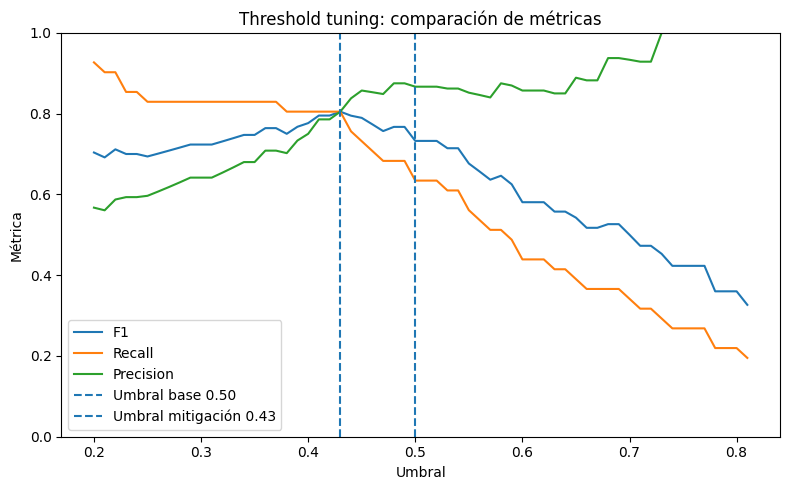

In [16]:
# =========================
# 13.1 Gráfico threshold tuning
# =========================

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
ax.axvline(0.50, linestyle="--", label="Umbral base 0.50")
ax.axvline(best_threshold, linestyle="--", label=f"Umbral mitigación {best_threshold:.2f}")

ax.set_xlabel("Umbral")
ax.set_ylabel("Métrica")
ax.set_ylim(0, 1)
ax.set_title("Threshold tuning: comparación de métricas")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "week9_threshold_tuning.png", dpi=180, bbox_inches="tight")
plt.show()


## 14. Comparación global antes vs después

Se compara el umbral base 0.50 contra el umbral mitigado.


In [17]:
# =========================
# 14. Antes vs después global
# =========================

df_slices["pred_base"] = (df_slices[PROB_COL] >= 0.50).astype(int)
df_slices["pred_mitigated"] = (df_slices[PROB_COL] >= best_threshold).astype(int)

base_metrics = compute_metrics(df_slices[TARGET_COL], df_slices["pred_base"], df_slices[PROB_COL])
mit_metrics = compute_metrics(df_slices[TARGET_COL], df_slices["pred_mitigated"], df_slices[PROB_COL])

before_after = pd.DataFrame([
    {"scenario": "baseline_threshold_0_50", "threshold": 0.50, **base_metrics, **confusion_counts(df_slices[TARGET_COL], df_slices["pred_base"])},
    {"scenario": "mitigated_threshold", "threshold": best_threshold, **mit_metrics, **confusion_counts(df_slices[TARGET_COL], df_slices["pred_mitigated"])}
])

delta = before_after.iloc[1].copy()
delta["scenario"] = "delta_mitigation_minus_baseline"
for col in ["accuracy", "precision", "recall", "f1", "pr_auc", "tn", "fp", "fn", "tp"]:
    delta[col] = before_after.iloc[1][col] - before_after.iloc[0][col]
delta["threshold"] = best_threshold - 0.50
delta["n"] = 0

before_after = pd.concat([before_after, pd.DataFrame([delta])], ignore_index=True)

display(before_after)
before_after.to_csv(LOGS_DIR / "week9_before_after_global.csv", index=False, encoding="utf-8-sig")


,scenario,threshold,n,accuracy,precision,recall,f1,pr_auc,tn,fp,fn,tp
0,baseline_threshold_0_50,0.50,88,0.784091,0.866667,0.634146,0.732394,0.853188,43,4,15,26
1,mitigated_threshold,0.43,88,0.818182,0.804878,0.804878,0.804878,0.853188,39,8,8,33
2,delta_mitigation_minus_baseline,-0.07,0,0.034091,-0.061789,0.170732,0.072484,0.000000,-4,4,-7,7


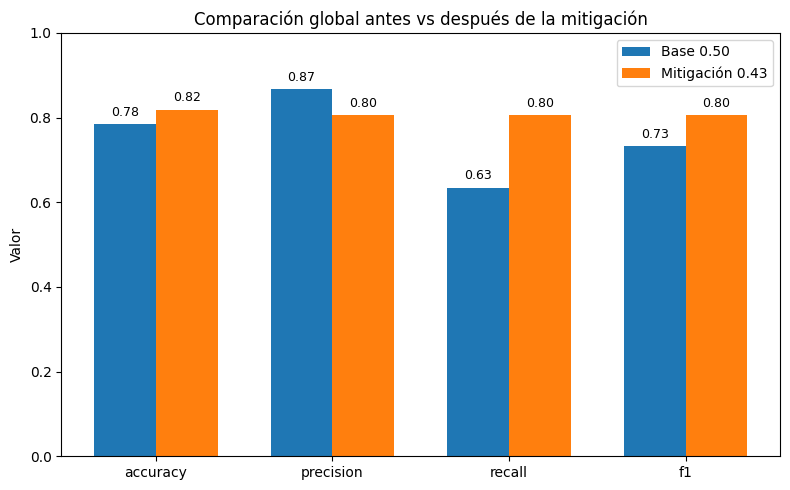

In [18]:
# =========================
# 14.1 Gráfico antes vs después global
# =========================

metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
plot_ba = before_after[before_after["scenario"].isin(["baseline_threshold_0_50", "mitigated_threshold"])].copy()

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
baseline_values = plot_ba.iloc[0][metrics_to_plot].values.astype(float)
mitigated_values = plot_ba.iloc[1][metrics_to_plot].values.astype(float)

ax.bar(x - width/2, baseline_values, width, label="Base 0.50")
ax.bar(x + width/2, mitigated_values, width, label=f"Mitigación {best_threshold:.2f}")

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_ylabel("Valor")
ax.set_title("Comparación global antes vs después de la mitigación")
ax.legend()

for i, v in enumerate(baseline_values):
    ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
for i, v in enumerate(mitigated_values):
    ax.text(i + width/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / "week9_before_after_global.png", dpi=180, bbox_inches="tight")
plt.show()


## 15. Comparación por slices problemáticos

La mitigación se evalúa también dentro de los slices problemáticos.


In [19]:
# =========================
# 15. Antes vs después por slice problemático
# =========================

slice_before_after_rows = []

for _, row in top_problematic.iterrows():
    group = row["slice_group"]
    value = row["slice_value"]
    sub = df_slices[df_slices[group].astype(str) == str(value)].copy()

    y_true_sub = sub[TARGET_COL].astype(int).values
    y_score_sub = sub[PROB_COL].values

    pred_base_sub = (y_score_sub >= 0.50).astype(int)
    pred_mit_sub = (y_score_sub >= best_threshold).astype(int)

    base_m = compute_metrics(y_true_sub, pred_base_sub, y_score_sub)
    mit_m = compute_metrics(y_true_sub, pred_mit_sub, y_score_sub)

    slice_before_after_rows.append({
        "slice_group": group,
        "slice_value": value,
        "scenario": "baseline",
        "threshold": 0.50,
        **base_m,
        **confusion_counts(y_true_sub, pred_base_sub)
    })

    slice_before_after_rows.append({
        "slice_group": group,
        "slice_value": value,
        "scenario": "mitigated",
        "threshold": best_threshold,
        **mit_m,
        **confusion_counts(y_true_sub, pred_mit_sub)
    })

slice_before_after_df = pd.DataFrame(slice_before_after_rows)

display(slice_before_after_df)
slice_before_after_df.to_csv(LOGS_DIR / "week9_before_after_problematic_slices.csv", index=False, encoding="utf-8-sig")


,slice_group,slice_value,scenario,threshold,n,accuracy,precision,recall,f1,pr_auc,tn,fp,fn,tp
0,slice_time_window,final_periodo,baseline,0.50,29,0.482759,0.800000,0.380952,0.516129,0.801947,6,2,13,8
1,slice_time_window,final_periodo,mitigated,0.43,29,0.655172,0.866667,0.619048,0.722222,0.801947,6,2,8,13
2,slice_time_window,inicio_periodo,baseline,0.50,30,0.933333,0.000000,0.000000,0.000000,NaN,28,2,0,0
3,slice_time_window,inicio_periodo,mitigated,0.43,30,0.866667,0.000000,0.000000,0.000000,NaN,26,4,0,0
4,slice_news_volume,volumen_medio,baseline,0.50,29,0.758621,0.600000,0.375000,0.461538,0.523565,19,2,5,3
5,slice_news_volume,volumen_medio,mitigated,0.43,29,0.724138,0.500000,0.500000,0.500000,0.523565,17,4,4,4
6,slice_confidence,confianza_baja,baseline,0.50,30,0.666667,0.818182,0.529412,0.642857,0.749978,11,2,8,9
7,slice_confidence,confianza_baja,mitigated,0.43,30,0.766667,0.727273,0.941176,0.820513,0.749978,7,6,1,16
8,slice_strength,intensidad_baja,baseline,0.50,30,0.700000,0.833333,0.588235,0.689655,0.831563,11,2,7,10
9,slice_strength,intensidad_baja,mitigated,0.43,30,0.800000,0.823529,0.823529,0.823529,0.831563,10,3,3,14


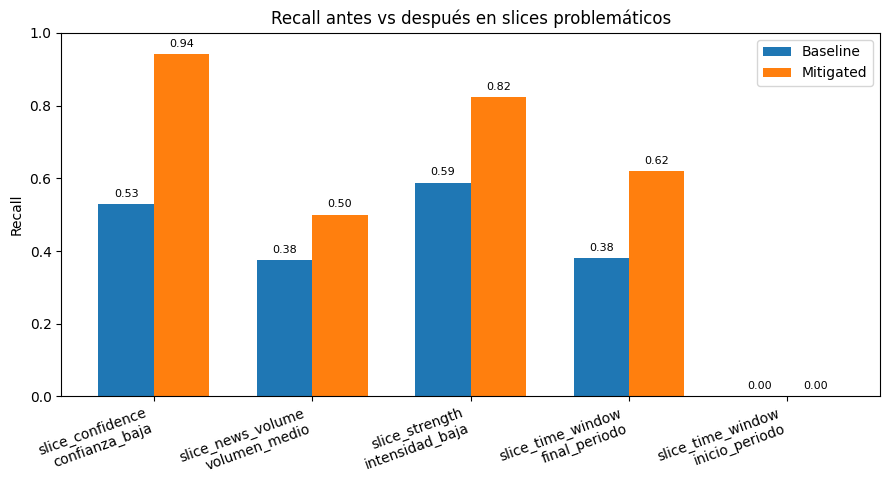

In [20]:
# =========================
# 15.1 Gráfico recall antes vs después en slices problemáticos
# =========================

plot_df = slice_before_after_df.copy()
plot_df["slice_label"] = plot_df["slice_group"] + "\n" + plot_df["slice_value"].astype(str)

pivot = plot_df.pivot_table(
    index="slice_label",
    columns="scenario",
    values="recall",
    aggfunc="first"
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pivot))
width = 0.35

ax.bar(x - width/2, pivot["baseline"], width, label="Baseline")
ax.bar(x + width/2, pivot["mitigated"], width, label="Mitigated")

ax.set_xticks(x)
ax.set_xticklabels(pivot["slice_label"], rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Recall")
ax.set_title("Recall antes vs después en slices problemáticos")
ax.legend()

for i, v in enumerate(pivot["baseline"]):
    ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(pivot["mitigated"]):
    ax.text(i + width/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / "week9_before_after_problematic_slices_recall.png", dpi=180, bbox_inches="tight")
plt.show()


## 16. Exportar resumen para informe y dashboard

Se generan archivos `.csv`, `.json` y figuras para el informe Overleaf.


In [21]:
# =========================
# 16. Exportar resumen consolidado
# =========================

summary = {
    "model": MODEL_NAME,
    "base_threshold": 0.50,
    "mitigated_threshold": best_threshold,
    "n_modelable": int(len(df_slices)),
    "base_accuracy": float(base_metrics["accuracy"]),
    "base_precision": float(base_metrics["precision"]),
    "base_recall": float(base_metrics["recall"]),
    "base_f1": float(base_metrics["f1"]),
    "base_pr_auc": float(base_metrics["pr_auc"]),
    "mit_accuracy": float(mit_metrics["accuracy"]),
    "mit_precision": float(mit_metrics["precision"]),
    "mit_recall": float(mit_metrics["recall"]),
    "mit_f1": float(mit_metrics["f1"]),
    "mit_pr_auc": float(mit_metrics["pr_auc"]),
    "generated_at": pd.Timestamp.now().isoformat()
}

with open(LOGS_DIR / "week9_error_analysis_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

# Export para dashboard
slice_metrics_df.to_csv(DOCS_DATA_DIR / "week9_slice_metrics_base.csv", index=False, encoding="utf-8-sig")
bootstrap_df.to_csv(DOCS_DATA_DIR / "week9_slice_bootstrap_ci.csv", index=False, encoding="utf-8-sig")
before_after.to_csv(DOCS_DATA_DIR / "week9_before_after_global.csv", index=False, encoding="utf-8-sig")
slice_before_after_df.to_csv(DOCS_DATA_DIR / "week9_before_after_problematic_slices.csv", index=False, encoding="utf-8-sig")
top_problematic.to_csv(DOCS_DATA_DIR / "week9_top_problematic_slices.csv", index=False, encoding="utf-8-sig")

print("Resumen Week9:")
display(pd.DataFrame([summary]))

print("\nArchivos generados en logs:")
for f in sorted(LOGS_DIR.glob("week9_*")):
    print("-", f.name)

print("\nArchivos generados en figs:")
for f in sorted(FIGS_DIR.glob("week9_*")):
    print("-", f.name)

print("\nArchivos exportados a docs/data:")
for f in sorted(DOCS_DATA_DIR.glob("week9_*")):
    print("-", f.name)


Resumen Week9:


,model,base_threshold,mitigated_threshold,n_modelable,base_accuracy,base_precision,base_recall,base_f1,base_pr_auc,mit_accuracy,mit_precision,mit_recall,mit_f1,mit_pr_auc,generated_at
0,Random Forest ganador,0.5,0.43,88,0.784091,0.866667,0.634146,0.732394,0.853188,0.818182,0.804878,0.804878,0.804878,0.853188,2026-07-03T17:39:57.118240



Archivos generados en logs:
- week9_before_after_global.csv
- week9_before_after_problematic_slices.csv
- week9_best_threshold.csv
- week9_confusion_matrix_base.csv
- week9_dataset_with_slices.csv
- week9_error_analysis_summary.json
- week9_false_negatives.csv
- week9_false_positives.csv
- week9_global_base_metrics.csv
- week9_predictions_with_error_type.csv
- week9_slice_bootstrap_ci.csv
- week9_slice_metrics_base.csv
- week9_threshold_tuning.csv
- week9_top_problematic_slices.csv

Archivos generados en figs:
- week9_before_after_global.png
- week9_before_after_problematic_slices_recall.png
- week9_confusion_matrix_base.png
- week9_slice_confidence_f1.png
- week9_slice_neutrality_recall.png
- week9_slice_news_volume_recall.png
- week9_slice_strength_recall.png
- week9_slice_time_window_recall.png
- week9_threshold_tuning.png
- week9_top_problematic_slices.png

Archivos exportados a docs/data:
- week9_before_after_global.csv
- week9_before_after_problematic_slices.csv
- week9_slice_bo